# TF-IDF / LSA Semantic Features

Extracts non-FinBERT semantic features from 10-K text using TF-IDF and Latent Semantic Analysis (LSA).

FinBERT captures sentence-level sentiment toward ESG topics. TF-IDF/LSA captures the overall **vocabulary and topic mix** of each filing — which terms and themes co-occur across the corpus — giving the model a complementary signal about what each company is actually talking about.

**Pipeline:**
1. Concatenate Business + Risk Factors + MD&A text per company
2. Fit TF-IDF (2,000 features, min_df=3, English stop words removed) on all 323 companies
3. Apply TruncatedSVD (LSA) to reduce to 50 latent topic components
4. Inspect top terms per component and correlations with ESG targets

**Note on leakage:** TF-IDF + TruncatedSVD is fully unsupervised (no ESG labels used), so fitting on all 323 companies does not constitute label leakage. The final modeling notebook applies the train/test split downstream.

**Output:** `data/finbert_features/lsa_features.csv` (323 rows × 51 cols including ticker)

## Step 1 — Imports and Configuration

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

SECTIONS_DIR = "../data/extracted_sections"
QUALITY_CSV  = "../data/structured_features/extraction_quality.csv"
ESG_CSV      = "../data/ESG_data_cleaned.csv"
OUTPUT_CSV   = "../data/finbert_features/lsa_features.csv"

N_COMPONENTS  = 50   # LSA latent dimensions
MAX_FEATURES  = 2000 # TF-IDF vocabulary size
MIN_DF        = 3    # term must appear in at least 3 documents
RANDOM_STATE  = 42
SECTIONS      = ["business", "risk_factors", "mda"]

print("Imports OK")

Imports OK


## Step 2 — Load Text Corpus

In [2]:
quality = pd.read_csv(QUALITY_CSV)
modeling_tickers = set(quality.loc[quality["bad_extraction"] != 2, "ticker"])
available = {f.replace(".json", "") for f in os.listdir(SECTIONS_DIR) if f.endswith(".json")}
tickers = sorted(modeling_tickers & available)
print(f"Companies: {len(tickers)}")

corpus = []
for ticker in tickers:
    with open(os.path.join(SECTIONS_DIR, f"{ticker}.json"), "r", encoding="utf-8") as f:
        data = json.load(f)
    sections = data.get("sections", {})
    combined = " ".join(sections.get(s, "") for s in SECTIONS)
    corpus.append(combined)

word_counts = [len(doc.split()) for doc in corpus]
print(f"Corpus word counts — min: {min(word_counts)}, median: {int(np.median(word_counts))}, max: {max(word_counts)}")

Companies: 323
Corpus word counts — min: 1101, median: 31890, max: 184423


## Step 3 — Fit TF-IDF → LSA Pipeline

In [3]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=MAX_FEATURES,
        min_df=MIN_DF,
        stop_words="english",
        sublinear_tf=True,   # log(1+tf) dampens high-frequency term dominance
        ngram_range=(1, 2),  # unigrams + bigrams to capture phrases like 'climate risk'
    )),
    ("lsa", TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)),
])

lsa_matrix = pipeline.fit_transform(corpus)
print(f"LSA matrix shape: {lsa_matrix.shape}")

explained = pipeline.named_steps["lsa"].explained_variance_ratio_
print(f"Variance explained — top 10 components: {explained[:10].sum():.3f}, all 50: {explained.sum():.3f}")

LSA matrix shape: (323, 50)
Variance explained — top 10 components: 0.375, all 50: 0.611


## Step 4 — Inspect Top Terms per Component

In [4]:
vocab = pipeline.named_steps["tfidf"].get_feature_names_out()
components = pipeline.named_steps["lsa"].components_  # shape: (n_components, n_features)

print("Top 10 terms per LSA component (first 15 components):\n")
for i in range(15):
    top_idx = np.argsort(np.abs(components[i]))[::-1][:10]
    top_terms = ", ".join(vocab[top_idx])
    var = explained[i]
    print(f"Component {i:2d} (var={var:.4f}): {top_terms}")

Top 10 terms per LSA component (first 15 components):

Component  0 (var=0.0073): business, financial, 2021, including, operations, results, million, products, 2020, related
Component  1 (var=0.1547): clinical, clinical trials, product candidates, fda, trials, patients, clinical trial, trial, product candidate, drugs
Component  2 (var=0.0551): mortgage, manufacturing, semiconductor, real estate, underwriting, holding company, lending, financial services, borrower, estate
Component  3 (var=0.0390): natural gas, gas, clients, pension, fuel, cloud, emissions, client, subscription, plant
Component  4 (var=0.0269): adjusted ebitda, ebitda, financial services, reit, banking, reinsurance, risk management, clients, rent, convertible
Component  5 (var=0.0220): stores, merchandise, fiscal 2021, semiconductor, fiscal 2020, retailers, industrial, store, brands, guests
Component  6 (var=0.0210): fuel, electric, natural gas, emissions, gas, oil, renewable, carbon, utility, aircraft
Component  7 (var

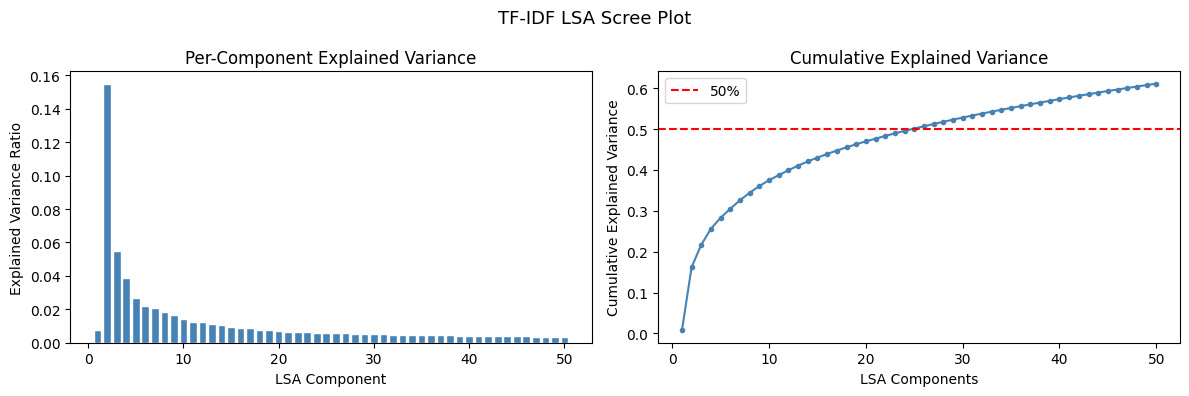

Scree plot saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, N_COMPONENTS + 1), explained, color="steelblue", edgecolor="white")
axes[0].set_xlabel("LSA Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Per-Component Explained Variance")

axes[1].plot(range(1, N_COMPONENTS + 1), np.cumsum(explained), marker="o", markersize=3, color="steelblue")
axes[1].axhline(0.5, color="red", linestyle="--", label="50%")
axes[1].set_xlabel("LSA Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.suptitle("TF-IDF LSA Scree Plot", fontsize=13)
plt.tight_layout()
plt.savefig("../data/finbert_features/lsa_scree_plot.png", dpi=120, bbox_inches="tight")
plt.show()
print("Scree plot saved.")

## Step 5 — Build Feature DataFrame

In [6]:
col_names = [f"lsa_{i:02d}" for i in range(N_COMPONENTS)]
df = pd.DataFrame(lsa_matrix, columns=col_names)
df.insert(0, "ticker", tickers)

print(f"Feature dataframe shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head(3)

Feature dataframe shape: (323, 51)
Missing values: 0


,ticker,lsa_00,lsa_01,lsa_02,lsa_03,lsa_04,lsa_05,lsa_06,lsa_07,lsa_08,...,lsa_40,lsa_41,lsa_42,lsa_43,lsa_44,lsa_45,lsa_46,lsa_47,lsa_48,lsa_49
0,A,0.880402,0.032965,-0.119661,0.057763,-0.042127,-0.054611,-0.085916,0.061025,0.023310,...,-0.050066,0.002497,-0.062021,0.035031,0.044781,-0.015241,-0.010960,0.017968,0.027388,0.017814
1,AADI,0.830188,0.510593,0.008505,0.010881,-0.000315,0.006659,0.008712,0.011497,-0.005777,...,-0.018696,0.007801,0.009829,-0.005444,0.007159,0.006089,0.006119,-0.006325,-0.013510,-0.003141
2,AAL,0.857489,-0.050796,0.082452,-0.018682,0.022788,0.019643,0.207538,0.026550,-0.047030,...,-0.017514,-0.021644,-0.032325,0.042414,-0.055510,0.031932,0.001882,-0.014977,0.049073,0.030839


## Step 6 — Correlation with ESG Targets

Merged rows: 323

Top 10 LSA components by |r| with total_score:
lsa_01    0.295218
lsa_04    0.185614
lsa_11    0.171699
lsa_41    0.154677
lsa_22    0.152389
lsa_07    0.150711
lsa_00    0.148618
lsa_08    0.146082
lsa_05    0.141819
lsa_03    0.110328
Name: total_score, dtype: float64


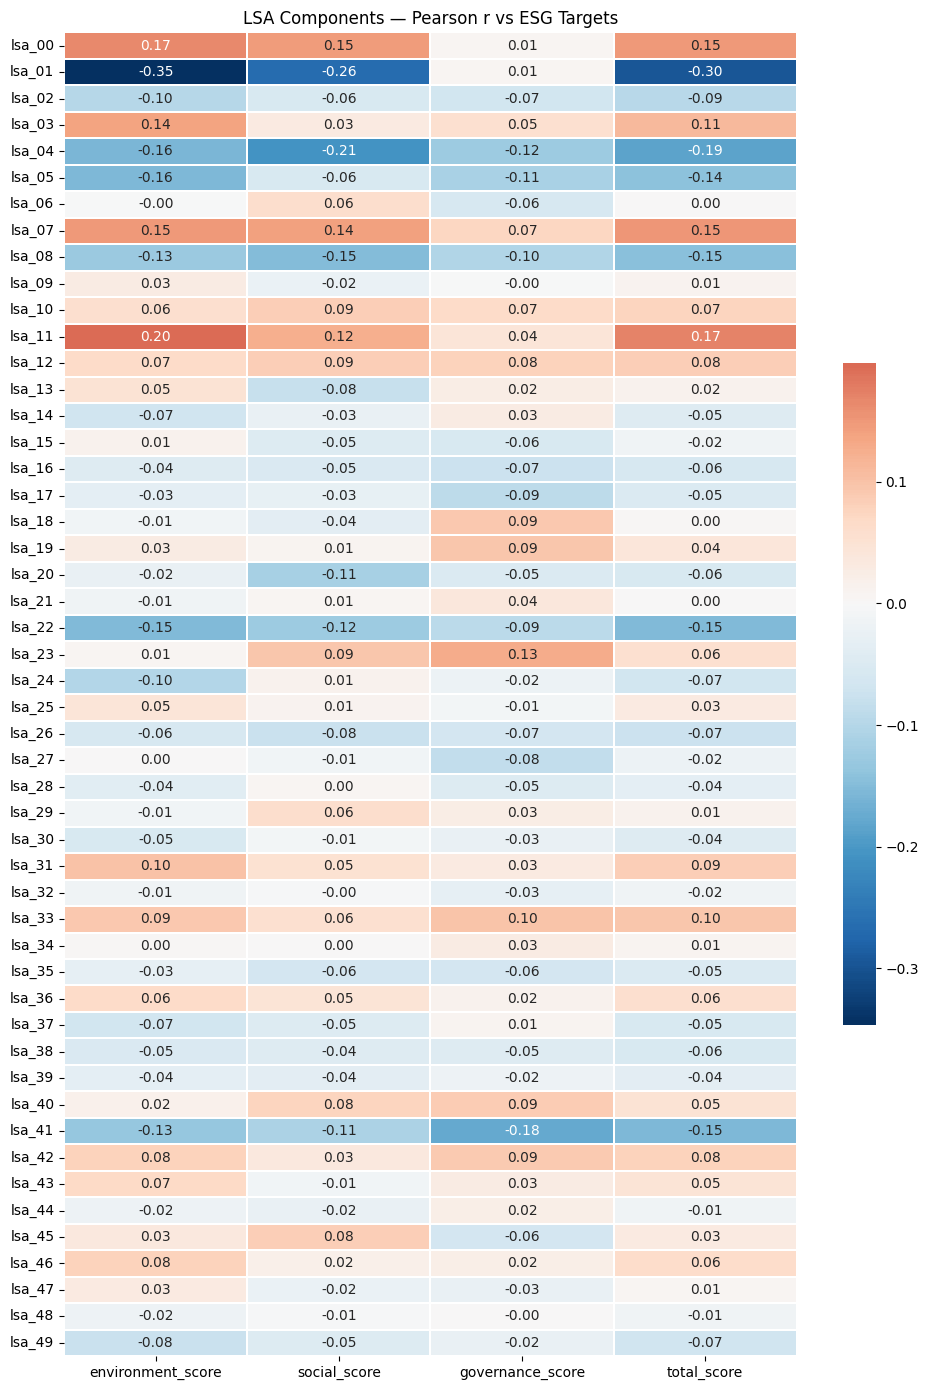

Heatmap saved.


In [7]:
esg = pd.read_csv(ESG_CSV)[["ticker", "environment_score", "social_score", "governance_score", "total_score"]]
esg["ticker"] = esg["ticker"].str.upper()
merged = df.merge(esg, on="ticker", how="inner")
print(f"Merged rows: {len(merged)}")

targets   = ["environment_score", "social_score", "governance_score", "total_score"]
corr = merged[col_names + targets].corr()[targets].loc[col_names]

print("\nTop 10 LSA components by |r| with total_score:")
print(corr["total_score"].abs().sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 14))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.3, cbar_kws={"shrink": 0.5})
plt.title("LSA Components — Pearson r vs ESG Targets")
plt.tight_layout()
plt.savefig("../data/finbert_features/lsa_corr_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()
print("Heatmap saved.")

## Step 7 — Save Output

In [8]:
df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved: {df.shape[0]} rows x {df.shape[1]} cols -> {OUTPUT_CSV}")

Saved: 323 rows x 51 cols -> ../data/finbert_features/lsa_features.csv
